# Интерполяционные многочлены (вариант 2)

In [3]:
import sympy as sm
x = sm.Symbol('x')

## Многочлен Лагранжа

$$
L_n(x) = \sum\limits_{i=0}^n y_i \prod\limits_{j=0, j \neq i}^n \frac{(x-x_j)}{(x_i-x_j)}
$$

Используя интерполяционную формулу Лагранжа для неравноотстоящих узлов:
1) построить многочлен Лагранжа (вывести формулу)
2) вывести график многочлена Лагранжа на заданном промежутке
2) вычислить значения функции при данных значениях аргумента
4) отметить на графике (разными цветами) узлы интерполяции,а так же предсказанные значения функции.

In [123]:
X1 = [0.02, 0.08, 0.12, 0.17, 0.23, 0.30]
Y1 = [1.02316, 1.09590, 1.14725, 1.21483, 1.30120, 1.40976]

X1_extra = [0.102, 0.114, 0.125, 0.203, 0.154]

In [124]:
n = len(X1)
L = 0
for i in range(0, n):
    L_temp = Y1[i]
    for j in range(0, n):
        if i != j:
            L_temp *= (x - X1[j]) / (X1[i] - X1[j])
    L += L_temp

L = sm.expand(L)
print('Многочлен Лагранжа:')
L

Многочлен Лагранжа:


-0.327274136792767*x**5 + 0.37687180543071*x**4 + 0.15092222591079*x**3 + 0.669437881343242*x**2 + 1.14388338175059*x + 1.00001329058243

In [125]:
L_x = sm.lambdify(x, L)
Y1_extra = list()

for i in range(0, len(X1_extra)):
    Y1_extra.append(L_x(X1_extra[i]))

print('Значения y для дополнительных значений x:')
Y1_extra

Значения y для дополнительных значений x:


[1.1238515675573209,
 1.1393969594887245,
 1.1538354722738087,
 1.2615981868880908,
 1.192782551484549]

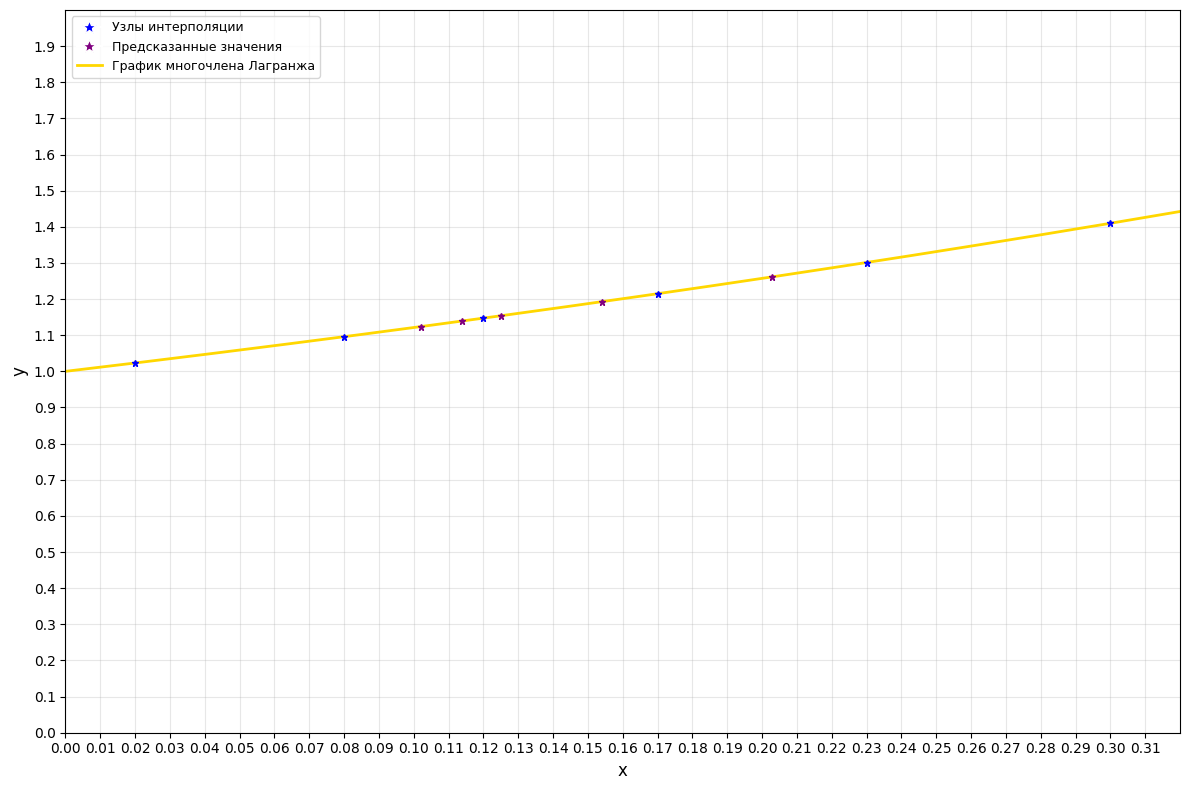

In [127]:
import matplotlib.pyplot as plt
import numpy as np

x_points = X1_extra
y_points = Y1_extra

#>>>-----------------Задаём диапазон значений и функции---------------------->
x_min = X1[0] + 0.02
x_max = X1[-1] + 0.02
x_plot = np.linspace(0, 1, 800)
y_plot = L_x(x_plot)

#>>>-----------------Задаем фигуру---------------------->
fig, ax = plt.subplots(figsize=(12, 8))

#>>>-----------------Настройка графика---------------------->
ax.set_xlim(0, 0.32)
ax.set_ylim(0, 2)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.grid(True, alpha=0.3)  # Включаем сетку (alpha - прозрачность)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5) 
ax.set_xticks(np.arange(0, 0.32, 0.01))
ax.set_yticks(np.arange(0, 2, 0.1))

#>>>-----------------Строим графики, ставим точки---------------------->
ax.plot(x_plot, y_plot, color='gold', linewidth=2)

for i in range(0, 5):
    ax.plot(x_points[i], y_points[i], '*', markersize=5, color='purple')
    
for i in range(0, 6):
    ax.plot(X1[i], Y1[i], '*', markersize=5, color='blue')

#>>>-----------------Легенда---------------------->
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=10, label='Узлы интерполяции'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='purple', markersize=10, label='Предсказанные значения'),
    Line2D([0], [0], color='gold', linewidth=2, label='График многочлена Лагранжа'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Формула Ньютона

* Используя таблицу значений функции, рассчитать и показать таблицу конечных разностей.
* По таблице конечных разностей построить первую и вторую формулы Ньютона.
* Вычислить указанные значения функции при данных значениях аргумента.

### Строим таблицу конечных разностей

In [17]:
X2 = [0.101, 0.106, 0.111, 0.116, 0.121, 0.126, 0.131, 0.136, 0.141, 0.146, 0.151]
Y2 = [1.26183, 1.27644, 1.29122, 1.306617, 1.32130, 1.33660, 1.35207, 1.36773, 1.38357, 1.39959, 1.41579]

In [18]:
deltas = dict()

#>>>-----------------Вычисление Δ---------------------->
for i in range(0, len(X2) - 1):  #i - номер y j - степень дельты
    deltas[(i, 1)] = Y2[i + 1] - Y2[i]

#>>>-----------------Вычисление степеней Δ---------------------->
for j in range(2, len(X2)):  #i - номер y j - степень дельты
    for i in range(0, len(X2) - j):
        deltas[(i, j)] = deltas[(i + 1, j - 1)] - deltas[(i, j - 1)]


In [19]:
n = len(X2)
max_deg = n - 1

# Заголовки
headers = ["x", "y"] + [f"Δ^{j}y" if j > 1 else "Δy" for j in range(1, max_deg + 1)]
col_w = 12
print("".join(h.ljust(col_w) for h in headers))
print("-" * col_w * len(headers))

for i in range(n):
    row = [str(X2[i]), str(Y2[i])]
    for j in range(1, max_deg + 1):
        if (i, j) in deltas:
            row.append(f"{deltas[(i, j)]:.5f}")
        else:
            row.append("-")
    print("".join(v.ljust(col_w) for v in row))


x           y           Δy          Δ^2y        Δ^3y        Δ^4y        Δ^5y        Δ^6y        Δ^7y        Δ^8y        Δ^9y        Δ^10y       
------------------------------------------------------------------------------------------------------------------------------------------------
0.101       1.26183     0.01461     0.00017     0.00045     -0.00178    0.00444     -0.00888    0.01556     -0.02499    0.03770     -0.05427    
0.106       1.27644     0.01478     0.00062     -0.00133    0.00266     -0.00444    0.00668     -0.00943    0.01271     -0.01657    -           
0.111       1.29122     0.01540     -0.00071    0.00133     -0.00178    0.00224     -0.00274    0.00328     -0.00387    -           -           
0.116       1.306617    0.01468     0.00062     -0.00045    0.00047     -0.00050    0.00054     -0.00059    -           -           -           
0.121       1.3213      0.01530     0.00017     0.00002     -0.00003    0.00004     -0.00005    -           -           -         

### Строим первую формулу Ньютона

Первая интерполяционная формула (интерполяция вперёд):
$$
P_n(x) = y_0 + \frac{\Delta y_0}{h}(x - x_0) + \frac{\Delta^2 y_0}{2!h^2}(x - x_0)(x-x_1) + ... 
+ \frac{\Delta^n y_0}{n!h^n}(x - x_0)...(x-x_{n-1})
$$

In [20]:
h = X2[1] - X2[0]
P1 = Y2[0] #тут должна получаться первая интерп-я формула Ньютона
n = len(X2)

for i in range(1, n):
    P1_temp = deltas[(0, i)] / (h ** i) / sm.factorial(i)
    for j in range(0, i):
        P1_temp *= x - X2[j]
    P1 += P1_temp

#P1

In [21]:
P1 = sm.expand(P1)
P1

-1.53142857142785e+15*x**10 + 1.9445037037028e+15*x**9 - 1.10902869841219e+15*x**8 + 374140029637926.0*x**7 - 82677585587252.1*x**6 + 12504585387159.2*x**5 - 1310885971057.07*x**4 + 94052934886.7992*x**3 - 4419874113.69728*x**2 + 122844817.192157*x - 1533422.22084908

### Строим вторую формулу Ньютона

Вторая интерполяционная формула (интерполяция назад):
$$
P_n(x) = y_n + \frac{\Delta y_{n-1}}{h}(x - x_n) + \frac{\Delta^2 y_{n-2}}{2!h^2}(x - x_n)(x-x_{n-1}) + ... 
+ \frac{\Delta^n y_0}{n!h^n}(x - x_n)...(x-x_1)
$$

In [22]:
h = X2[1] - X2[0]
P2 = Y2[-1] #тут должна получаться вторая интерп-я формула Ньютона
n = len(X2)

for i in range(1, n):
    P2_temp = deltas[(n - 1 - i, i)] / (h ** i) / sm.factorial(i)
    for j in range(0, i):
        P2_temp *= x - X2[n - 1 -j]
    P2 += P2_temp

#P2

In [115]:
P2 = sm.expand(P2)
P2

-1.53142857142785e+15*x**10 + 1.9445037037028e+15*x**9 - 1.10902869841219e+15*x**8 + 374140029637926.0*x**7 - 82677585587252.1*x**6 + 12504585387159.2*x**5 - 1310885971057.07*x**4 + 94052934886.7993*x**3 - 4419874113.69728*x**2 + 122844817.192157*x - 1533422.22084908

### Вычисление Y для дополнительных X

In [23]:
X2_extra = [0.1026, 0.1440, 0.099, 0.153]

In [25]:
P1_x = sm.lambdify(x, P1)
P2_x = sm.lambdify(x, P2)
Y2_extra = list()

for i in range(0, len(X2_extra)):
    if (X2[-1] - X2_extra[i]) ** 2 > (X2[0] - X2_extra[i]) ** 2:
        Y2_extra.append(P1_x(X2_extra[i]))
    else:
        Y2_extra.append(P2_x(X2_extra[i]))

print('Значения y для дополнительных значений x:')
Y2_extra

Значения y для дополнительных значений x:


[1.2687695901840925,
 1.3930085023574428,
 1.2376191820949316,
 1.4136925530876399]

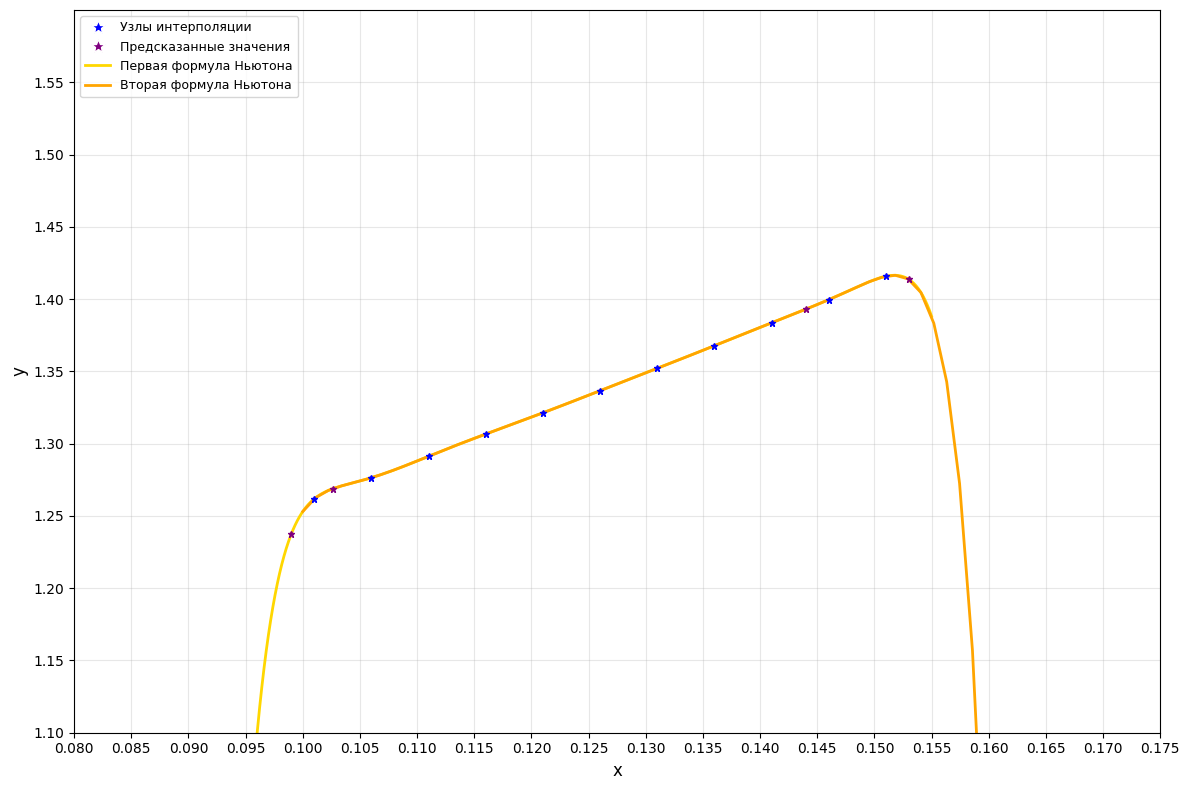

In [26]:
import matplotlib.pyplot as plt
import numpy as np

x_points = X2_extra
y_points = Y2_extra

#>>>-----------------Задаём диапазон значений и функции---------------------->
x_min = X2[0] + 0.05
x_max = X2[-1] + 0.05
x_plot_1 = np.linspace(0, 0.155, 800)
y_plot_1 = P1_x(x_plot_1)
x_plot_2 = np.linspace(0.10, 1, 800)
y_plot_2 = P2_x(x_plot_2)

#>>>-----------------Задаем фигуру---------------------->
fig, ax = plt.subplots(figsize=(12, 8))

#>>>-----------------Настройка графика---------------------->
ax.set_xlim(0.08, 0.17)
ax.set_ylim(1.1, 1.6)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.grid(True, alpha=0.3)  # Включаем сетку (alpha - прозрачность)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5) 
ax.set_xticks(np.arange(0.08, 0.18, 0.005))
ax.set_yticks(np.arange(1.1, 1.6, 0.05))

#>>>-----------------Строим графики, ставим точки---------------------->
ax.plot(x_plot_1, y_plot_1, color='gold', linewidth=2)
ax.plot(x_plot_2, y_plot_2, color='orange', linewidth=2)

for i in range(0, 4):
    ax.plot(x_points[i], y_points[i], '*', markersize=5, color='purple')
    
for i in range(0, 11):
    ax.plot(X2[i], Y2[i], '*', markersize=5, color='blue')

#>>>-----------------Легенда---------------------->
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=10, label='Узлы интерполяции'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='purple', markersize=10, label='Предсказанные значения'),
    Line2D([0], [0], color='gold', linewidth=2, label='Первая формула Ньютона'),
    Line2D([0], [0], color='orange', linewidth=2, label='Вторая формула Ньютона'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Отдельная функция

Для $y = \ln(x+1)$ составим таблицу из 10 значений на отрезке $[2.5; 2.7]$ Построим интерполяционный многочлен. Вичислим значение в произвольной точке.

In [4]:
X3 = list()
Y3 = list()
k = 0.02

for i in range(0, 10):
    X3.append(2.5 + i * k)
    Y3.append(float(sm.log(3.5 + i * k)))

print(X3)
print(Y3)

[2.5, 2.52, 2.54, 2.56, 2.58, 2.6, 2.62, 2.64, 2.66, 2.68]
[1.252762968495368, 1.2584609896100056, 1.264126727145683, 1.269760544863939, 1.275362800412609, 1.2809338454620645, 1.2864740258376797, 1.2919836816486494, 1.297463147413275, 1.3029127521808397]


In [5]:
deltas = dict()

#>>>-----------------Вычисление Δ---------------------->
for i in range(0, len(X3) - 1):  #i - номер y j - степень дельты
    deltas[(i, 1)] = Y3[i + 1] - Y3[i]

#>>>-----------------Вычисление степеней Δ---------------------->
for j in range(2, len(X3)):  #i - номер y j - степень дельты
    for i in range(0, len(X3) - j):
        deltas[(i, j)] = deltas[(i + 1, j - 1)] - deltas[(i, j - 1)]

In [6]:
n = len(X3)
max_deg = n - 1

# Заголовки
headers = ["x", "y"] + [f"Δ^{j}y" if j > 1 else "Δy" for j in range(1, max_deg + 1)]
col_w = 12
print("".join(h.ljust(col_w) for h in headers))
print("-" * col_w * len(headers))

for i in range(n):
    row = [str(X3[i]), str(Y3[i])]
    for j in range(1, max_deg + 1):
        if (i, j) in deltas:
            row.append(f"{deltas[(i, j)]:.5f}")
        else:
            row.append("-")
    print("".join(v.ljust(col_w) for v in row))

x           y           Δy          Δ^2y        Δ^3y        Δ^4y        Δ^5y        Δ^6y        Δ^7y        Δ^8y        Δ^9y        
------------------------------------------------------------------------------------------------------------------------------------
2.5         1.2527629684953680.00570     -0.00003    0.00000     -0.00000    0.00000     -0.00000    0.00000     -0.00000    0.00000     
2.52        1.25846098961000560.00567     -0.00003    0.00000     -0.00000    0.00000     -0.00000    0.00000     0.00000     -           
2.54        1.2641267271456830.00563     -0.00003    0.00000     -0.00000    0.00000     -0.00000    0.00000     -           -           
2.56        1.2697605448639390.00560     -0.00003    0.00000     -0.00000    0.00000     -0.00000    -           -           -           
2.58        1.2753628004126090.00557     -0.00003    0.00000     -0.00000    0.00000     -           -           -           -           
2.6         1.28093384546206450.00554     -

In [15]:
#>>>-----------------Интерполяция вперёд---------------------->
h = X3[1] - X3[0]
P3 = Y3[0] #тут должна получаться первая интерп-я формула Ньютона
n = len(X3)

for i in range(1, n):
    P3_temp = deltas[(0, i)] / (h ** i) / sm.factorial(i)
    for j in range(0, i):
        P3_temp *= x - X3[j]
    P3 += P3_temp


In [16]:
P3 = sm.expand(P3)
P3

9.56086571856698e-5*x**9 - 0.00223035875482731*x**8 + 0.0231414062111911*x**7 - 0.140243078531393*x**6 + 0.547707893924206*x**5 - 1.43348001151909*x**4 + 2.53470204647227*x**3 - 3.01340590662423*x**2 + 2.64819884015153*x - 0.477274058326988

In [11]:
P3_x = sm.lambdify(x, P3)
X3_extra = 2.515
Y3_extra = P3_x(X3_extra)

print(f'Значение y = {Y3_extra} для дополнительного значения x = {X3_extra}')

Значение y = 1.2570395252627398 для дополнительного значения x = 2.515


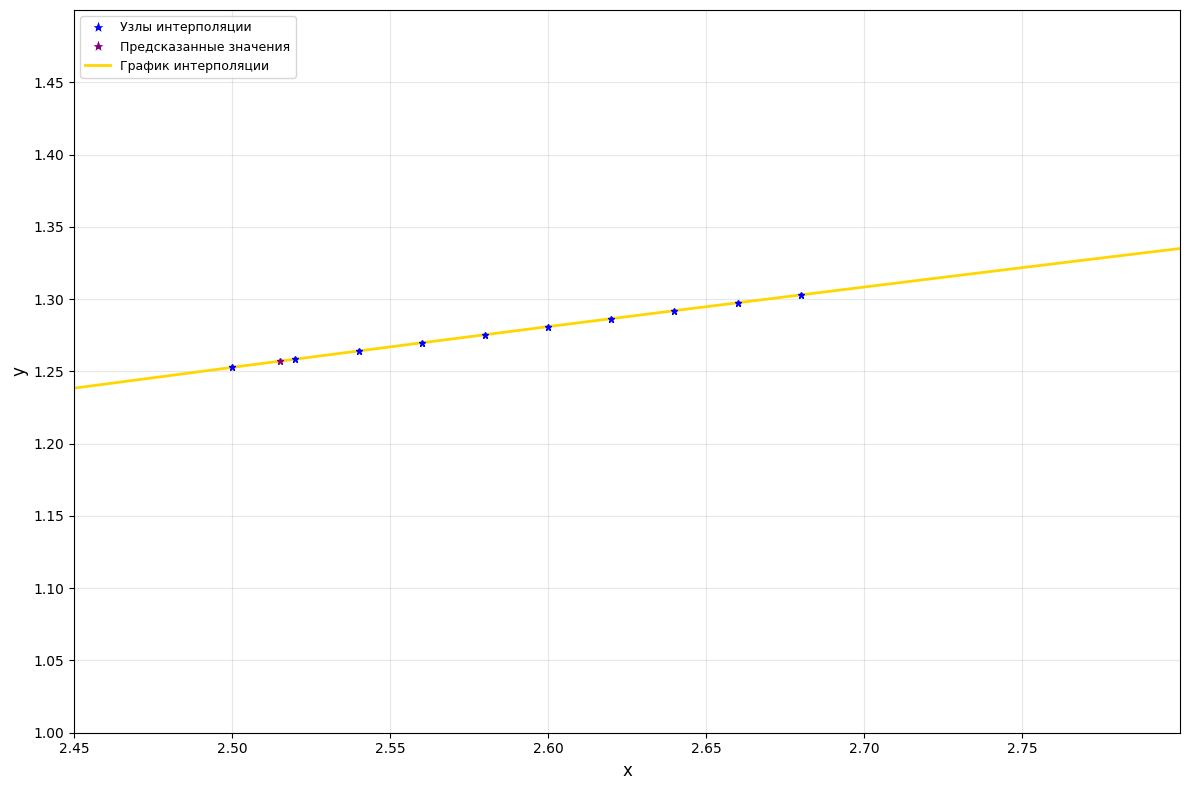

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x_points = X3_extra
y_points = Y3_extra

#>>>-----------------Задаём диапазон значений и функции---------------------->
x_min = X3[0] + 0.05
x_max = X3[-1] + 0.05
x_plot = np.linspace(0, 3, 800)
y_plot = P3_x(x_plot)

#>>>-----------------Задаем фигуру---------------------->
fig, ax = plt.subplots(figsize=(12, 8))

#>>>-----------------Настройка графика---------------------->
ax.set_xlim(2.45, 2.8)
ax.set_ylim(1, 1.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.grid(True, alpha=0.3)  # Включаем сетку (alpha - прозрачность)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5) 
ax.set_xticks(np.arange(2.45, 2.8, 0.05))
ax.set_yticks(np.arange(1, 1.5, 0.05))

#>>>-----------------Строим графики, ставим точки---------------------->
ax.plot(x_plot, y_plot, color='gold', linewidth=2)
ax.plot(x_points, y_points, '*', markersize=5, color='purple')

#for i in range(0, 4):
#    ax.plot(x_points[i], y_points[i], '*', markersize=5, color='purple')
    
for i in range(0, 10):
    ax.plot(X3[i], Y3[i], '*', markersize=5, color='blue')

#>>>-----------------Легенда---------------------->
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=11, label='Узлы интерполяции'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='purple', markersize=11, label='Предсказанные значения'),
    Line2D([0], [0], color='gold', linewidth=2, label='График интерполяции'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()